<a href="https://colab.research.google.com/github/nallapaneni991001/Random-Forest/blob/Random_Forest/Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Classification with Random Forest**

* This code uses the RandomForestClassifier class from the sklearn module to train a RandomForest classifier on the breast cancer dataset.

* The fit() method is used to train the classifier on the training data, and the predict() method is used to predict the class labels of the test data.

* The score() method is used to evaluate the accuracy of the classifier on the test data.

##**1. Import libraries**

In [ ]:
# Import important libraries
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split


##**2. Load your dataset**

Breast cancer dataset: This dataset contains measurements of breast cancer cells, with the goal of classifying them as benign or malignant.

In [ ]:
from sklearn.datasets import load_breast_cancer

# Load the dataset
data_cancer = load_breast_cancer()

# Convert the features and target to a dataframe
Data_breast_cancer = pd.DataFrame(data_cancer .data, columns=data_cancer.feature_names)
Data_breast_cancer['target'] = pd.Series(data_cancer.target)

##**3. Visualised your dataset**

In [ ]:
# Let view the first five rows of our data
Data_breast_cancer.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
#Check if there a missing values
Data_breast_cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
# Check shape
Data_breast_cancer.shape

(569, 31)

##**4. Sperate your data into independent (x) and dependent (y) variables**

In [ ]:
#Independent variables (x)
X_variables = Data_breast_cancer.drop(["target"], axis=1)

#Dependent variable (y)
y_variable = Data_breast_cancer["target"]

In [ ]:
# Scale the X_variable using MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_variables_scaled = scaler.fit_transform(X_variables)

##**5. Split your data into train and test**

In [ ]:
# Split the data into training (75%) and testing sets (25%)
X_train, X_test, y_train, y_test = train_test_split(X_variables_scaled, y_variable, test_size=0.25, random_state=42)

##**6. Creat your model**

In [ ]:
# Create a DecisionTreeClassifier object
RF_model = RandomForestClassifier(n_estimators=100, random_state= 42)

##**7. Train (fit) your RF model**

In [ ]:
# Train the classifier on the training data
RF_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

##**8. Test (Evaluate the performance) of your RF model**

In [ ]:
# Predict the class labels of the test data
y_pred = RF_model.predict(X_test)

##**9. Check the eveluation metric of your model**

Let calculate the following metrics of our DT_model based on y_pred
 * accuracy,
 * recall,
 * precision,
 * F1-Score,
 * AUC,
 * confusion matrix

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.965034965034965
Precision: 0.9666666666666667
Recall: 0.9775280898876404
F1 Score: 0.9720670391061451
AUC: 0.9609862671660424
Confusion Matrix:
 [[51  3]
 [ 2 87]]


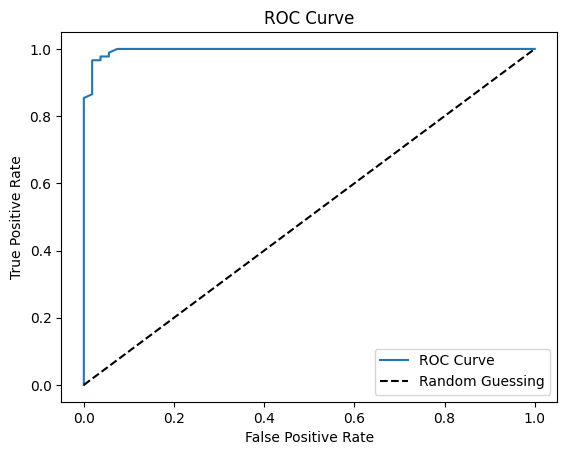

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

y_pred_prob = RF_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


## **10. Important feature**

In [ ]:
importance = RF_model.feature_importances_
indices = np.argsort(importance)[::-1]
features = X_variables.columns

# Print the feature ranking
print("Feature ranking:")

for f in range(X_variables.shape[1]):
    print("%d. %s (%f)" % (f + 1, features[indices[f]], importance[indices[f]]))

Feature ranking:
1. worst concave points (0.172295)
2. worst area (0.123192)
3. mean concave points (0.090299)
4. mean concavity (0.083215)
5. worst radius (0.081277)
6. worst perimeter (0.071388)
7. mean perimeter (0.053146)
8. area error (0.043551)
9. mean area (0.042780)
10. mean radius (0.039711)
11. worst concavity (0.031740)
12. radius error (0.019517)
13. worst texture (0.016490)
14. worst compactness (0.015801)
15. mean texture (0.014604)
16. worst symmetry (0.013103)
17. mean compactness (0.011402)
18. worst smoothness (0.010335)
19. perimeter error (0.008682)
20. mean smoothness (0.008165)
21. concavity error (0.007014)
22. fractal dimension error (0.006583)
23. worst fractal dimension (0.005182)
24. concave points error (0.005047)
25. smoothness error (0.004644)
26. texture error (0.004600)
27. mean symmetry (0.004435)
28. mean fractal dimension (0.004434)
29. symmetry error (0.003714)
30. compactness error (0.003655)


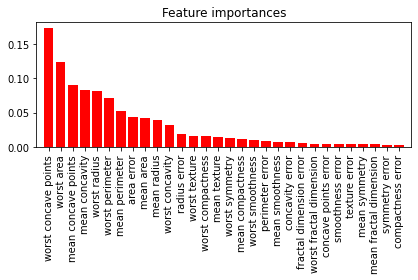

In [ ]:
importance = RF_model.feature_importances_
indices = np.argsort(importance)[::-1]
features = X_variables.columns

# Create a bar chart of feature importances
plt.figure()
plt.title("Feature importances")
plt.bar(range(X_variables.shape[1]), importance[indices],
        color="r", align="center")
plt.xticks(range(X_variables.shape[1]), features[indices], rotation=90)
plt.xlim([-1, X_variables.shape[1]])
plt.tight_layout()
plt.show()